In [1]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from sklearn.metrics import roc_auc_score, roc_curve, auc
import copy
import re
from plotnine import *
import scanpy as sc
from scipy.stats import mannwhitneyu, spearmanr

# set_style()
sns.set_theme(style='ticks')
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['font.size'] = 10
plt.rcParams['text.usetex'] = False
plt.rcParams['font.sans-serif'] = ['Arial']
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['pdf.fonttype'] = 42

In [2]:
meta_df = (
    pd.read_parquet('./data/macrophages_metadata.parquet')
    .query('perturbation != "control"')
)
meta_df['cell_type'] = meta_df['cluster'].apply(lambda x: 'Macrophage' if x.startswith('Mac_') else 'Other')
meta_df['M1/M2'] = meta_df['cluster'].apply(lambda x: 'M2' if x in ['Mac_1', 'Mac_2', 'Mac_3'] else ('M1' if x in ['Mac_4'] else None))
our_proba_df = pd.read_parquet('./data/macrophages_proba_ours.parquet')
our_logit_df = our_proba_df.map(lambda x: np.log(x / (1 - x)))
our_relpos_df = (our_proba_df.shape[1] - our_proba_df.rank(axis=1, ascending=False) + 1) / our_proba_df.shape[1]
cellnavi_logit_df = (
    pd
    .read_csv('data/cellnavi_pred_macrophages_results_fix.csv.gz', index_col=0)
    .drop(columns=['control'])
)
cellnavi_proba_df = (
    pd
    .read_csv('data/cellnavi_pred_macrophages_results_fix.csv.gz', index_col=0)
    .transform(lambda x: np.exp(x) / np.exp(x).sum(), axis=1)
    .drop(columns=['control'])
)
cellnavi_relpos_df = (cellnavi_proba_df.shape[1] - cellnavi_proba_df.rank(axis=1, ascending=False) + 1) / cellnavi_proba_df.shape[1]

In [3]:
cellnavi_relpos_df

,AIP,ARPC2,ATP6V1A,ATP6V1B2,ATP6V1E1,BIRC3,CFDP1,EGLN1,EIF5,HCFC1,...,TRAF2,TRIB1,UBE2F,UBE2N,USP9X,VHL,VIRMA,VPS4B,WTAP,ZC3H13
YS5_TKR180900693_HT3YJCCXY_L4_sc60,0.810811,0.891892,0.351351,0.432432,0.243243,0.324324,0.513514,0.621622,0.081081,0.918919,...,0.108108,0.216216,0.594595,0.162162,0.540541,0.378378,0.459459,0.486486,1.000000,0.864865
YS5_TKR180900693_HT3YJCCXY_L4_sc64,0.729730,0.486486,0.405405,0.513514,0.189189,0.081081,0.837838,0.756757,0.270270,0.918919,...,0.216216,0.351351,0.297297,0.135135,0.567568,0.243243,0.324324,0.027027,0.648649,0.621622
YS5_TKR180900693_HT3YJCCXY_L4_sc66,0.729730,0.837838,0.567568,0.378378,0.459459,0.189189,0.351351,0.783784,0.324324,0.486486,...,0.054054,0.243243,0.162162,0.081081,0.648649,0.594595,0.297297,0.540541,0.891892,0.972973
YS5_TKR180900693_HT3YJCCXY_L4_sc67,0.783784,0.918919,0.459459,0.513514,0.108108,0.324324,0.405405,0.621622,0.054054,0.729730,...,0.270270,0.567568,0.594595,0.135135,0.378378,0.162162,0.486486,0.216216,1.000000,0.810811
YS5_TKR180900693_HT3YJCCXY_L4_sc74,0.783784,0.540541,0.729730,0.675676,0.486486,0.270270,0.702703,0.432432,0.135135,0.810811,...,0.108108,0.405405,0.216216,0.081081,0.621622,0.324324,0.297297,0.189189,0.918919,1.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
L3_FKDL190665156.1a_sc44,0.648649,0.243243,0.729730,0.621622,0.918919,0.405405,0.189189,0.540541,0.162162,0.783784,...,0.324324,0.594595,0.081081,0.054054,0.297297,0.378378,0.486486,0.108108,1.000000,0.972973
L3_FKDL190665156.1a_sc45,0.783784,0.675676,0.621622,0.594595,0.513514,0.378378,0.351351,0.648649,0.162162,0.756757,...,0.135135,0.567568,0.486486,0.027027,0.243243,0.270270,0.432432,0.081081,1.000000,0.891892
L3_FKDL190665156.1a_sc46,0.810811,0.621622,0.729730,0.540541,0.351351,0.135135,0.270270,0.459459,0.162162,0.675676,...,0.243243,0.513514,0.405405,0.081081,0.297297,0.378378,0.486486,0.108108,0.972973,0.945946
L3_FKDL190665156.1a_sc47,0.756757,0.648649,0.702703,0.513514,0.540541,0.243243,0.135135,0.486486,0.162162,0.621622,...,0.216216,0.594595,0.405405,0.108108,0.324324,0.351351,0.432432,0.081081,1.000000,0.945946


In [4]:
subtype_drivers_dict = {
    "Macrophage": ['ARPC2', 'STK11'],
    "Other": ['ARPC2', 'STK11'], # for comparing specificity
}

## cluster of M2 score vs proba

In [5]:
scatterplot_df = pd.concat([
    pd.merge(
        meta_df[['M1/M2', 'M2_score']],
        our_relpos_df[subtype_drivers_dict['Macrophage']],
        left_index=True,
        right_index=True
    ).assign(method='Ours'),
    pd.merge(
        meta_df[['M1/M2', 'M2_score']],
        cellnavi_relpos_df[subtype_drivers_dict['Macrophage']],
        left_index=True,
        right_index=True
    ).assign(method='CellNavi'),
], axis=0)
scatterplot_df

,M1/M2,M2_score,ARPC2,STK11,method
B1_TKR180900709_HT3YJCCXY_L6_sc1,None,-0.275689,0.405405,0.432432,Ours
B1_TKR180900709_HT3YJCCXY_L6_sc2,None,-0.293249,0.297297,0.594595,Ours
B1_TKR180900709_HT3YJCCXY_L6_sc5,None,-0.191078,0.513514,0.324324,Ours
B1_TKR180900709_HT3YJCCXY_L6_sc55,None,-0.269430,0.135135,0.675676,Ours
B1_TKR180900709_HT3YJCCXY_L6_sc56,None,0.002447,0.459459,0.270270,Ours
...,...,...,...,...,...
YS9_TKR181200321_sc47,None,-0.408258,0.756757,0.810811,CellNavi
YS9_TKR181200321_sc48,None,-0.188504,0.621622,0.729730,CellNavi
YS9_TKR181200321_sc7,None,-0.139339,0.918919,0.702703,CellNavi
YS9_TKR181200321_sc8,None,-0.198900,1.000000,0.648649,CellNavi


## RelPos for Macrophage

In [6]:
def format_pvalue(p_value):
    if p_value > 0.05:
        pv = r'$p> 0.05$'
        print(p_value)
    elif p_value < 1e-300:
        pv = r'$p<10^{-300}$'
    else:
        pv = r'$p=' + rf'{p_value:.2e}'.replace('e', r'\times 10^{') + r'}$'
    return pv


In [7]:
drivers_relpos_list = []
for subtype, drivers in subtype_drivers_dict.items():
    cells = meta_df[meta_df['cell_type'] == subtype].index.tolist()
    our_ = our_relpos_df.loc[cells, drivers].copy().assign(method='Ours')
    cellnavi_ = cellnavi_relpos_df.loc[cells, drivers].copy().assign(method='CellNavi')
    drivers_relpos_list.append(pd.concat([our_, cellnavi_]).melt(id_vars='method', var_name='gene', value_name='RelPos').assign(subtype=subtype))
drivers_relpos_df = pd.concat(drivers_relpos_list)
drivers_relpos_df

,method,gene,RelPos,subtype
0,Ours,ARPC2,0.621622,Macrophage
1,Ours,ARPC2,0.945946,Macrophage
2,Ours,ARPC2,0.972973,Macrophage
3,Ours,ARPC2,0.972973,Macrophage
4,Ours,ARPC2,1.000000,Macrophage
...,...,...,...,...
2835,CellNavi,STK11,1.000000,Other
2836,CellNavi,STK11,0.810811,Other
2837,CellNavi,STK11,0.729730,Other
2838,CellNavi,STK11,0.702703,Other


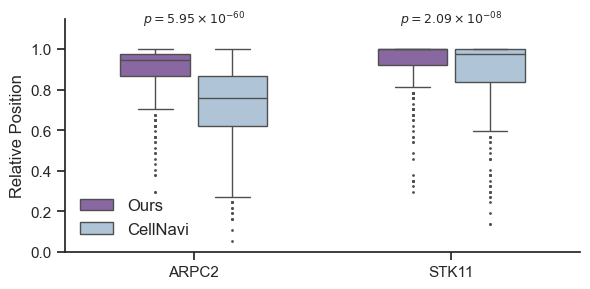

In [8]:
subtype = 'Macrophage'
fig, ax = plt.subplots(1, 1, figsize=(6, 3))
ax = sns.boxplot(
    data=drivers_relpos_df.query('subtype == @subtype'),
    x='gene', y='RelPos', hue='method',
    width=0.6,
    gap=0.1,
    fliersize=1,
    palette='BuPu_r',
    ax=ax
)
ax.set_ylim(0, 1.15)
ax.set_yticks([0, 0.2, 0.4, 0.6, 0.8, 1])
ax.set_ylabel('Relative Position')
ax.set_xlabel('')
ax.legend(frameon=False, fontsize=12, loc='lower left')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
# Add p-values
for j, gene in enumerate(subtype_drivers_dict[subtype]):
    our_data = drivers_relpos_df.query('subtype == @subtype & gene == @gene & method == "Ours"')['RelPos']
    cellnavi_data = drivers_relpos_df.query('subtype == @subtype & gene == @gene & method == "CellNavi"')['RelPos']
    p_value = mannwhitneyu(our_data, cellnavi_data, alternative='greater')[1]
    # p_value = mannwhitneyu(our_data, cellnavi_data)[1]
    # format p-value to scientific notation with x10^
    if p_value > 0.05:
        pv = r'$p> 0.05$'
        print(p_value)
    elif p_value < 1e-300:
        pv = r'$p<10^{-300}$'
    else:
        pv = r'$p=' + rf'{p_value:.2e}'.replace('e', r'\times 10^{') + r'}$'
    ax.text(j, 1.1, pv, ha='center', va='bottom', fontsize=9)
plt.tight_layout()
# plt.savefig('../figures/4_macrophages_benchmark_relpos_boxplot_fix.pdf')
plt.show()

In [9]:
drivers_relpos_df.head()

,method,gene,RelPos,subtype
0,Ours,ARPC2,0.621622,Macrophage
1,Ours,ARPC2,0.945946,Macrophage
2,Ours,ARPC2,0.972973,Macrophage
3,Ours,ARPC2,0.972973,Macrophage
4,Ours,ARPC2,1.000000,Macrophage


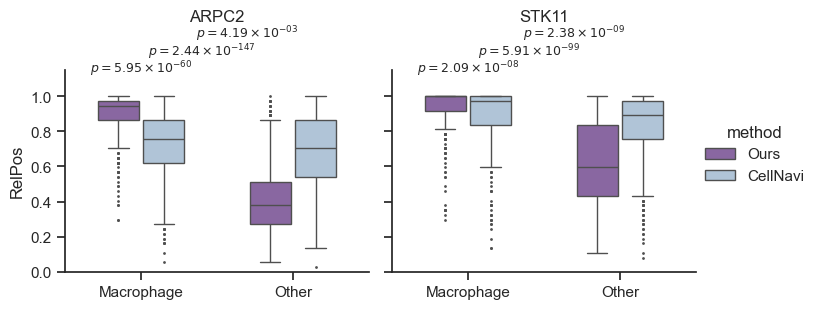

In [10]:
# fig, ax = plt.subplots(1, 2, figsize=(8, 3))
g = sns.catplot(
    kind='box',
    data=drivers_relpos_df,
    x='subtype', y='RelPos', hue='method',
    width=0.6,
    gap=0.1,
    fliersize=1,
    palette='BuPu_r',
    col='gene',
    height=3,
    aspect=1.2,
    # sharey=False,
)
g.set_titles('{col_name}', y=1.2)
for ax in g.axes.flat:
    ax.set_ylim(0, 1.15)
    ax.set_yticks([0, 0.2, 0.4, 0.6, 0.8, 1])
    ax.set_ylabel('RelPos')
    ax.set_xlabel('')
    # ax.legend(frameon=False, fontsize=12, loc='lower left')
    # ax.spines['top'].set_visible(False)
    # ax.spines['right'].set_visible(False)
    gene = ax.get_title()
    our_data_mac = drivers_relpos_df.query('subtype == "Macrophage" & gene == @gene & method == "Ours"')['RelPos']
    our_data_other = drivers_relpos_df.query('subtype == "Other" & gene == @gene & method == "Ours"')['RelPos']
    cellnavi_data_mac = drivers_relpos_df.query('subtype == "Macrophage" & gene == @gene & method == "CellNavi"')['RelPos']
    cellnavi_data_other = drivers_relpos_df.query('subtype == "Other" & gene == @gene & method == "CellNavi"')['RelPos']
    p_value_mac = mannwhitneyu(our_data_mac, cellnavi_data_mac, alternative='greater')[1]
    p_value_our = mannwhitneyu(our_data_mac, our_data_other, alternative='greater')[1]
    p_value_cellnavi = mannwhitneyu(cellnavi_data_mac, cellnavi_data_other, alternative='greater')[1]
    ax.text(0, 1.1, format_pvalue(p_value_mac), ha='center', va='bottom', fontsize=9)
    ax.text(0.4, 1.2, format_pvalue(p_value_our), ha='center', va='bottom', fontsize=9)
    ax.text(0.7, 1.3, format_pvalue(p_value_cellnavi), ha='center', va='bottom', fontsize=9)

# plt.tight_layout()
plt.savefig('../figures/4_macrophages_benchmark_relpos_boxplot_other_fix.pdf')
plt.show()

## RelPos for M2

In [12]:
subtype_drivers_dict_mac = {
    'M2': ['ARPC2', 'STK11'],
    # 'M1': ['ARPC2', 'STK11'],
}

In [13]:
drivers_relpos_list_mac = []
for subtype, drivers in subtype_drivers_dict_mac.items():   
    cells = meta_df[meta_df['M1/M2'] == subtype].index.tolist()
    our_ = our_relpos_df.loc[cells, drivers].copy().assign(method='Ours')
    cellnavi_ = cellnavi_relpos_df.loc[cells, drivers].copy().assign(method='CellNavi')
    drivers_relpos_list_mac.append(pd.concat([our_, cellnavi_]).melt(id_vars='method', var_name='gene', value_name='RelPos').assign(subtype=subtype))
drivers_relpos_df_mac = pd.concat(drivers_relpos_list_mac)

## AUC for Macrophage

In [14]:
colors = sns.color_palette('BuPu_r', 2)

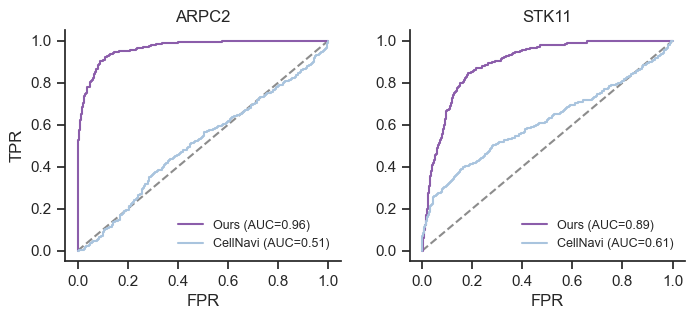

In [17]:
subtype = 'Macrophage'
fig, axes = plt.subplots(1, 2, figsize=(8, 3), gridspec_kw={'wspace': 0.25})
cells = meta_df[meta_df['cell_type'] == subtype].index.tolist()
our_label = our_proba_df.index.isin(cells)
cellnavi_label = cellnavi_proba_df.index.isin(cells)
for i, gene in enumerate(subtype_drivers_dict[subtype]):
    our_proba = our_proba_df[gene]
    cellnavi_proba = cellnavi_logit_df[gene]
    our_fpr, our_tpr, our_thresholds = roc_curve(our_label, our_proba)
    our_auc = auc(our_fpr, our_tpr)
    cellnavi_fpr, cellnavi_tpr, cellnavi_thresholds = roc_curve(cellnavi_label, cellnavi_proba)
    cellnavi_auc = auc(cellnavi_fpr, cellnavi_tpr)
    axes[i].plot([0, 1], [0, 1], 'k--', alpha=0.5)
    axes[i].plot(our_fpr, our_tpr, label=f'Ours (AUC={our_auc:.2f})', color=colors[0])
    axes[i].plot(cellnavi_fpr, cellnavi_tpr, label=f'CellNavi (AUC={cellnavi_auc:.2f})', color=colors[1])
    axes[i].set_title(gene)
    axes[i].set_xlabel('FPR')
    if i == 0:
        axes[i].set_ylabel('TPR')
    else:
        axes[i].set_ylabel('')
    axes[i].legend(frameon=False, fontsize=9, loc='lower right')
    axes[i].spines['top'].set_visible(False)
    axes[i].spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('../figures/4_macrophages_benchmark_roc_curve_fix.pdf', bbox_inches='tight')
plt.show()
    

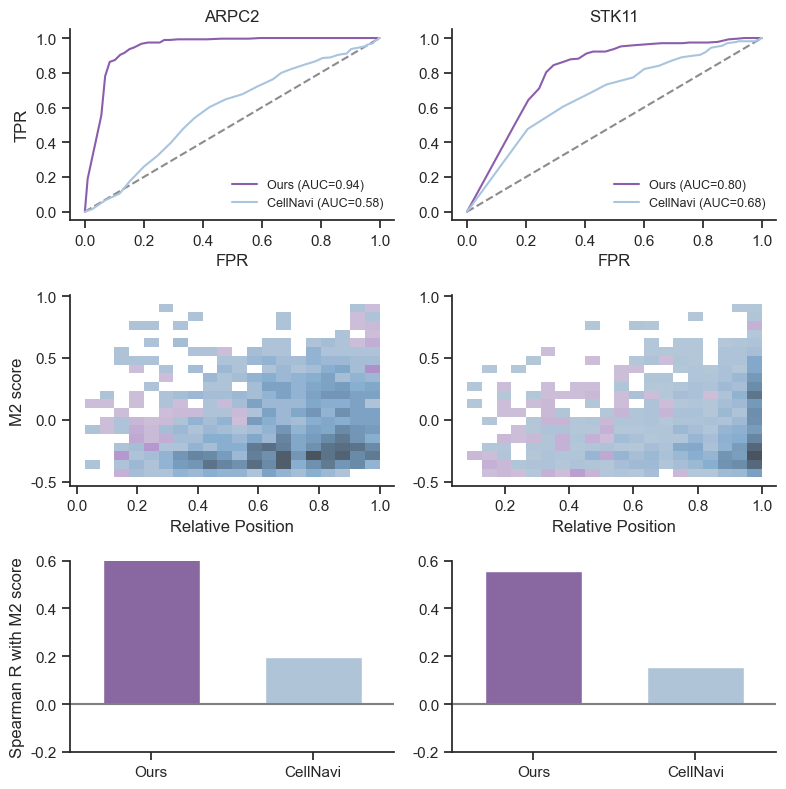

In [18]:
subtype = 'M2'
meta_mac_df = meta_df#.query('cell_type == "Macrophage"')
cells = meta_mac_df[meta_mac_df['M1/M2'] == subtype].index.tolist()
our_proba_df_mac = our_relpos_df.loc[meta_mac_df.index]
cellnavi_proba_df_mac = cellnavi_relpos_df.loc[meta_mac_df.index]
# our_label = our_proba_df_mac.index.isin(cells)
our_label = (meta_mac_df['M2_score'] > meta_mac_df['M1_score']) & (meta_mac_df['cell_type'] == 'Macrophage')
our_m2_score = meta_mac_df['M2_score']
our_m1_score = meta_mac_df['M1_score']
cellnavi_label = (meta_mac_df['M2_score'] > meta_mac_df['M1_score']) & (meta_mac_df['cell_type'] == 'Macrophage')
cellnavi_m2_score = meta_mac_df['M2_score']
cellnavi_m1_score = meta_mac_df['M1_score']
fig, axes = plt.subplots(3, 2, figsize=(8, 8))
for i, gene in enumerate(subtype_drivers_dict['Macrophage']):
    our_proba = our_proba_df_mac[gene]
    cellnavi_proba = cellnavi_proba_df_mac[gene]
    our_fpr, our_tpr, our_thresholds = roc_curve(our_label, our_proba)
    our_auc = auc(our_fpr, our_tpr)
    cellnavi_fpr, cellnavi_tpr, cellnavi_thresholds = roc_curve(cellnavi_label, cellnavi_proba)
    cellnavi_auc = auc(cellnavi_fpr, cellnavi_tpr)
    axes[0, i].plot([0, 1], [0, 1], 'k--', alpha=0.5)
    axes[0, i].plot(our_fpr, our_tpr, label=f'Ours (AUC={our_auc:.2f})', color=colors[0])
    axes[0, i].plot(cellnavi_fpr, cellnavi_tpr, label=f'CellNavi (AUC={cellnavi_auc:.2f})', color=colors[1])
    axes[0, i].set_title(gene)
    axes[0, i].set_xlabel('FPR')
    if i == 0:
        axes[0, i].set_ylabel('TPR')
    else:
        axes[0, i].set_ylabel('')
    axes[0, i].legend(frameon=False, fontsize=9, loc='lower right')
    axes[0, i].spines['top'].set_visible(False)
    axes[0, i].spines['right'].set_visible(False)
    
    # scatter plot
    plot_df_mac_ = pd.DataFrame({
        'proba': np.concatenate([our_proba, cellnavi_proba]),
        'm2_score': np.concatenate([our_m2_score, cellnavi_m2_score]),
        'method': np.concatenate([['Ours'] * len(our_proba), ['CellNavi'] * len(cellnavi_proba)]),
    })
    sns.histplot(
        data=plot_df_mac_,
        x='proba', y='m2_score', hue='method',
        # multiple='fill',
        bins=20,
        ax=axes[1, i],
        palette='BuPu_r',
        kde=True,
        common_norm=False,
    )
    axes[1, i].set_xlabel('Relative Position')
    if i == 0:
        axes[1, i].set_ylabel('M2 score')
    else:
        axes[1, i].set_ylabel('')
    # axes[2, i].set_title(gene)
    axes[1, i].spines['top'].set_visible(False)
    axes[1, i].spines['right'].set_visible(False)
    axes[1, i].legend(frameon=False, fontsize=9, loc='upper center', ncol=2, title='', bbox_to_anchor=(0.5, 1.1))
    
    # R^2
    our_m1_r = spearmanr(our_m1_score, our_proba)
    cellnavi_m1_r = spearmanr(cellnavi_m1_score, cellnavi_proba)
    our_m2_r = spearmanr(our_m2_score, our_proba)
    cellnavi_m2_r = spearmanr(cellnavi_m2_score, cellnavi_proba)
    plot_df_mac_ = pd.DataFrame([
        # {'subtype': 'M1', 'method': 'Ours', 'R': our_m1_r[0], 'p': our_m1_r[1]},
        # {'subtype': 'M1', 'method': 'CellNavi', 'R': cellnavi_m1_r[0], 'p': cellnavi_m1_r[1]},
        {'subtype': 'M2', 'method': 'Ours', 'R': our_m2_r[0], 'p': our_m2_r[1]},
        {'subtype': 'M2', 'method': 'CellNavi', 'R': cellnavi_m2_r[0], 'p': cellnavi_m2_r[1]},
    ])
    sns.barplot(
        data=plot_df_mac_,
        y='R', x='method', hue='method',
        # hue_order=['M2'],
        ax=axes[2, i],
        palette='BuPu_r',
        width=0.6,
    )
    axes[2, i].axhline(0, color='gray')
    if i == 0:
        axes[2, i].set_ylabel('Spearman R with M2 score')
    else:
        axes[2, i].set_ylabel('')
    # axes[2, i].legend(frameon=False, fontsize=9, loc='lower right')
    axes[2, i].spines['top'].set_visible(False)
    axes[2, i].spines['right'].set_visible(False)
    axes[2, i].set_xlabel('')
    axes[2, i].legend(frameon=False, fontsize=9, loc='upper right')
    axes[2, i].set_ylim(-0.2, 0.6)

plt.tight_layout()
plt.savefig('../figures/4_macrophages_benchmark_roc_hist_spearmanr_m2_fix.pdf')
plt.show()
    